In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. DATOS (ahora con 4 variables)
# -----------------------------
# y = 2*x1 + 3*x2 + 1.5*x3 + 4*x4

X = np.array([
    [1.0, 2.0, 0.5, 1.0],
    [2.0, 1.0, 1.2, 0.0],
    [3.0, 4.0, 0.7, 2.0],
    [4.0, 3.0, 1.5, 1.0],
    [5.0, 2.0, 0.3, 3.0],
    [1.5, 3.5, 2.0, 0.5]
])

y = np.array([
    [2*1.0 + 3*2.0 + 1.5*0.5 + 4*1.0],
    [2*2.0 + 3*1.0 + 1.5*1.2 + 4*0.0],
    [2*3.0 + 3*4.0 + 1.5*0.7 + 4*2.0],
    [2*4.0 + 3*3.0 + 1.5*1.5 + 4*1.0],
    [2*5.0 + 3*2.0 + 1.5*0.3 + 4*3.0],
    [2*1.5 + 3*3.5 + 1.5*2.0 + 4*0.5]
])

In [2]:
# 2. PARÁMETROS
# -----------------------------
np.random.seed(42)

input_size = 4
hidden1 = 16
hidden2 = 8
output_size = 1

W1 = np.random.randn(input_size, hidden1) * 0.1
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * 0.1
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, output_size) * 0.1
b3 = np.zeros((1, output_size))

In [3]:
# 3. FUNCIONES
# -----------------------------
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)



In [4]:
# 4. ENTRENAMIENTO
# -----------------------------
learning_rate = 0.01
epochs = 5000
n = X.shape[0]

losses = []

for epoch in range(epochs):
    # FORWARD
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    z3 = a2 @ W3 + b3
    y_pred = z3

    loss = mse(y, y_pred)
    losses.append(loss)

    # BACKPROP
    dL = (-2 / n) * (y - y_pred)

    dW3 = a2.T @ dL
    db3 = np.sum(dL, axis=0, keepdims=True)

    dA2 = dL @ W3.T
    dZ2 = dA2 * relu_derivative(z2)

    dW2 = a1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # UPDATE
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")


Epoch 0, Loss: 444.988607
Epoch 500, Loss: 51.946668
Epoch 1000, Loss: 51.946667
Epoch 1500, Loss: 51.946667
Epoch 2000, Loss: 51.946667
Epoch 2500, Loss: 51.946667
Epoch 3000, Loss: 51.946667
Epoch 3500, Loss: 51.946667
Epoch 4000, Loss: 51.946667
Epoch 4500, Loss: 51.946667


In [5]:
# 5. RESULTADOS
# -----------------------------
print("\nPredicciones finales:")
print(y_pred)

print("\nValores reales:")
print(y)


Predicciones finales:
[[19.8]
 [19.8]
 [19.8]
 [19.8]
 [19.8]
 [19.8]]

Valores reales:
[[12.75]
 [ 8.8 ]
 [27.05]
 [23.25]
 [28.45]
 [18.5 ]]


In [6]:
# 6. PRUEBA CON NUEVO DATO
# -----------------------------
X_new = np.array([[2.5, 1.5, 1.0, 2.0]])

z1_new = X_new @ W1 + b1
a1_new = relu(z1_new)

z2_new = a1_new @ W2 + b2
a2_new = relu(z2_new)

z3_new = a2_new @ W3 + b3

print("\nPredicción para nuevo dato [2.5, 1.5, 1.0, 2.0]:")
print(z3_new)


Predicción para nuevo dato [2.5, 1.5, 1.0, 2.0]:
[[19.8]]


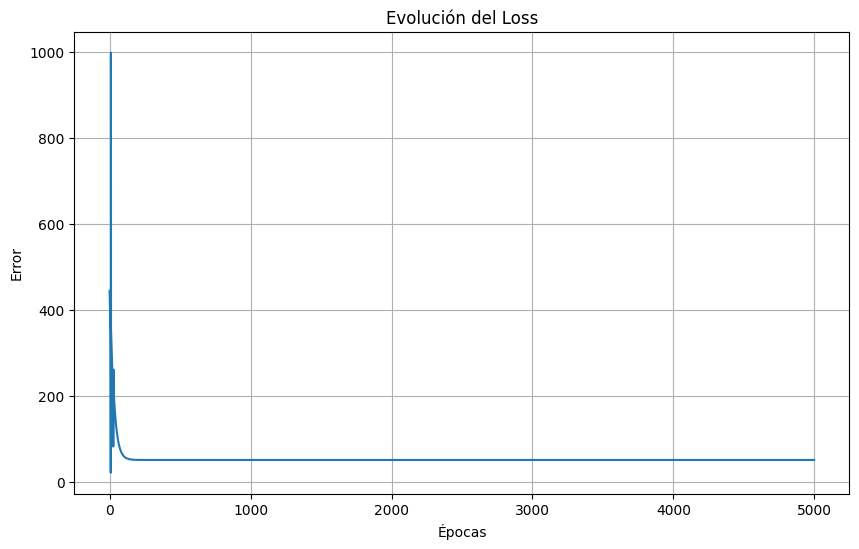

In [7]:
# 7. GRAFICAR LOSS
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title("Evolución del Loss")
plt.xlabel("Épocas")
plt.ylabel("Error")
plt.grid(True)
plt.savefig("loss_4_variables.png", dpi=300, bbox_inches="tight")
plt.show()

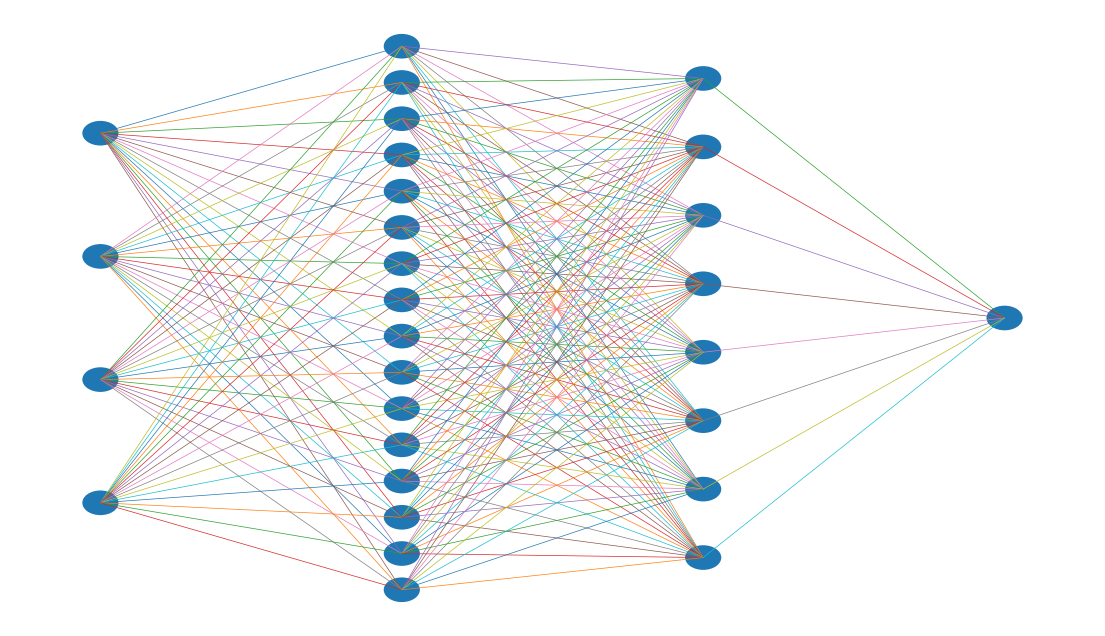

In [8]:
# 8. DIBUJAR RED
# -----------------------------
def draw_neural_net(layers):
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axis("off")

    n_layers = len(layers)
    x_spacing = 1.0 / (n_layers - 1)
    positions = []

    for i, layer_size in enumerate(layers):
        x = i * x_spacing
        y_spacing = 1.0 / (layer_size + 1)
        layer_positions = []

        for j in range(layer_size):
            y = 1 - (j + 1) * y_spacing
            layer_positions.append((x, y))

            circle = plt.Circle((x, y), 0.02, fill=True)
            ax.add_patch(circle)

        positions.append(layer_positions)

    for i in range(len(positions) - 1):
        for (x1, y1) in positions[i]:
            for (x2, y2) in positions[i + 1]:
                ax.plot([x1, x2], [y1, y2], linewidth=0.5)

    plt.xlim(-0.1, 1.1)
    plt.ylim(0, 1)
    plt.savefig("red_4_variables.png", dpi=300, bbox_inches="tight")
    plt.show()

draw_neural_net([4, 16, 8, 1])